# LKIPA Covariance Matrix Reconstruction
---

Here we reconstruct the covariance matrix from time series data

**Notes**
1. By splitting a pixel into chunks of length $\tau$ seconds, the frequency resolution $\Delta f$ of the TL modes is given by:

$$
    \boxed{
        \Delta f = \frac{1}{\tau}
    }
$$
For a resolution of $\Delta f = 10$ kHz, we need to split the pixel into chunks of $\tau = 100 \mu$ seconds each.  

2. Use ```AdcMode.Direct``` for full 2 GHz sampling and no I/Q downconversion. 

3. From real voltage time series, perform real FFT on each chunk to obtain I/Q quadratures. 

4. Generate covariance matrix for each chunk

5. Average covariance matrices over all chunks

In [322]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm

from presto import test
from presto import lockin, utils
from presto.hardware import AdcMode, DacMode, AdcFSample, DacFSample
import importlib
import LKIPA_PSD as psd
importlib.reload(psd)

<module 'LKIPA_PSD' from '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/LKIPA_PSD.py'>

# 1. Get Time Series pixels

In [323]:
# Number of pixels to be captured
N_PIX = 1000

# direct mode
CONVERTER_CONFIGURATION = {
    "adc_mode": AdcMode.Direct,
    "adc_fsample": AdcFSample.G2,
    "dac_mode": DacMode.Mixed04,
    "dac_fsample": DacFSample.G8,
}     

# DATA ACQUISITION
data_all, dt, fs, n_samples, myrun = psd.data_acquisition(
            address=psd.ADDRESS,
            port=psd.PORT,
            converter_configuration=CONVERTER_CONFIGURATION,
            input_port=psd.INPUT_PORT,
            adc_att=psd.ADC_ATT,
            input_nco=psd.INPUT_NCO,
            output_port=psd.FLUX_PORT,
            dac_curr=psd.DAC_CURR,
            amp=psd.PUMP_AMP,
            freq=psd.PUMP_FREQ,
            phasei=psd.PHASEI,
            phaseq=psd.PHASEQ,
            output_nco=psd.PUMP_NCO,
            df=psd.DF,
            dcb_port=psd.DC_PORT,
            dcb_amp=psd.DC_BIAS,
            n_pix=N_PIX
        )


Hardware configuration successful, initiating data acquisition ...


100%|███████████████████████████████████████| 1000/1000 [00:32<00:00, 30.67it/s]


Data Acquisition Complete.

MEASUREMENT PARAMETERS:
Mode: AdcMode.Direct
Number of pixels: 1000
Pixel time resolution (dt): 0.50 ns
Sampling frequency (fs): 2.00 GHz
Total measurement time: 100.0 µs
Frequency resolution (DF): 10.0 kHz
Data points captured per pixel: 200000
Number of samples per pixel: 200000


In [324]:
# REMOVE DC COMPONENT AND UNTWIST I\Q quadratures
I_all = psd.remove_DC(data_all=data_all, converter_configuration=CONVERTER_CONFIGURATION, n_pix=N_PIX)

# 2. Complex FFT to get I/Q for each pixel

In [330]:
t_list = dt * np.arange(0, n_samples, 1) * 1e-3    # μs, convert from ns seconds

# FFT
# ===

# frequency array for FFT
f_list = np.fft.fftfreq(n_samples, dt)  # Hz

fft_data_list = [] # np.zeros((N_PIX, n_samples))
for pix in range(N_PIX):
    fft_data_list.append(np.fft.fft(I_all[pix]))

# FFT of all time series
fft_data_list = np.array(fft_data_list)

# Only consider positive frequencies
pos = f_list >= 0
f_list_pos = f_list[pos]
fft_data_list_pos = fft_data_list[:, pos]

# Frequency dependent phase correction
dPhiDrift_df = 1.8869636024e-6
PhiDrift = dPhiDrift_df * f_list_pos
fft_data_list_pos = fft_data_list_pos * np.exp(-1j * PhiDrift)

# Quadrature separation
I_list = np.real(fft_data_list_pos)
Q_list = -1 * np.imag(fft_data_list_pos)

# 3. Generate covariance matrix for one pixel and average

## 3.1 Select bandwidth

In [331]:
f_L = 0.427
f_R = 0.429


L_idx = np.argmin(np.abs(f_list_pos - f_L))
R_idx = np.argmin(np.abs(f_list_pos - f_R))

f_list_pos_bandwidth = f_list_pos[L_idx: R_idx+1]
I_list_bandwidth = I_list[:, L_idx: R_idx+1]
Q_list_bandwidth = Q_list[:, L_idx: R_idx+1]

print(I_list_bandwidth.shape)

(1000, 201)


# 3.2 Create covariance matrix

In [332]:
# Build flattened quadrature vectors:
# shape = (N_PIX, 2 * n_modes)
# ordering: [X1, P1, X2, P2, ..., XM, PM]

n_modes = I_list_bandwidth.shape[1]

mode_ex = 50

u_list = np.empty((N_PIX, 2 * n_modes), dtype=float)
for pix in range(N_PIX):
    u_list[pix, 0::2] = I_list_bandwidth[pix, :]
    u_list[pix, 1::2] = Q_list_bandwidth[pix, :]

print(u_list.shape)
# Outer-product matrix for each pixel:
# shape = (2*n_modes, 2*n_modes)
cov_mat_list = np.empty((N_PIX, 2 * n_modes, 2 * n_modes), dtype=float)
for pix in range(N_PIX):
    cov_mat_list[pix] = u_list[pix, :, None] * u_list[pix, None, :]

cov_mat = np.mean(cov_mat_list, axis=0)


(1000, 402)


## 3.3 Plot

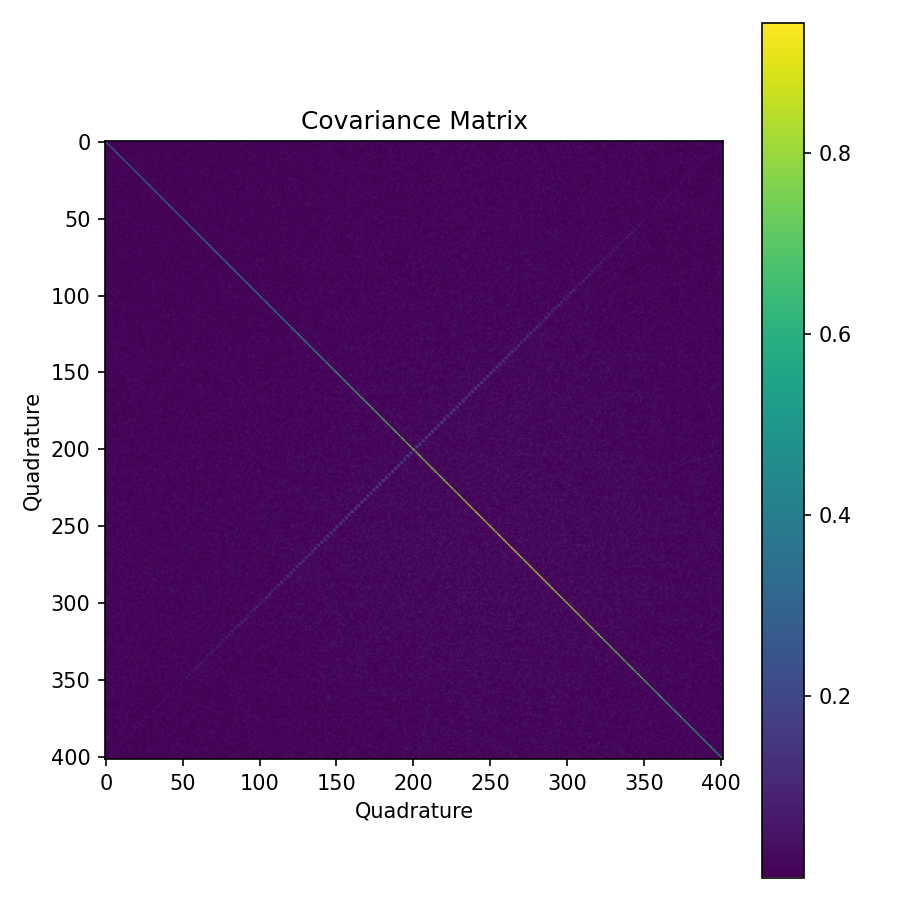

In [333]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

im = ax.imshow(
    np.abs(cov_mat),
    aspect='equal',
    cmap='viridis',
    origin='upper',
#    vmax=1,
#    vmin=-1e-9
)

cbar = fig.colorbar(im, ax=ax)


ax.set_xlabel("Quadrature")
ax.set_ylabel("Quadrature")
ax.set_title("Covariance Matrix")

fig.tight_layout()